<a href="https://colab.research.google.com/github/DevendraRaj58/Machine-Learning-Practicals/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Multiple Linear Regression Practical**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

In [ ]:
df_index=pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/economic_index.csv')
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)


In [ ]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


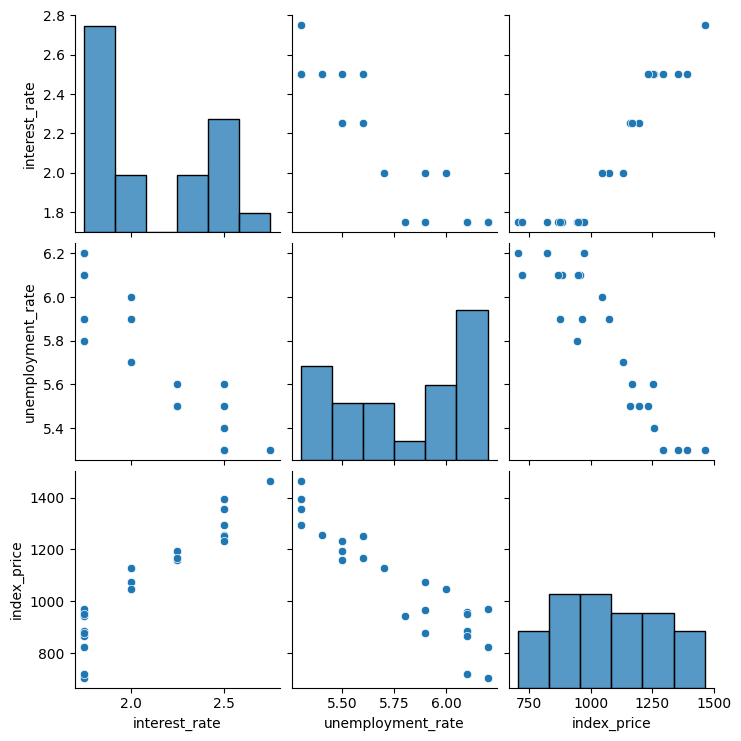

In [ ]:
sns.pairplot(df_index)

<Axes: >

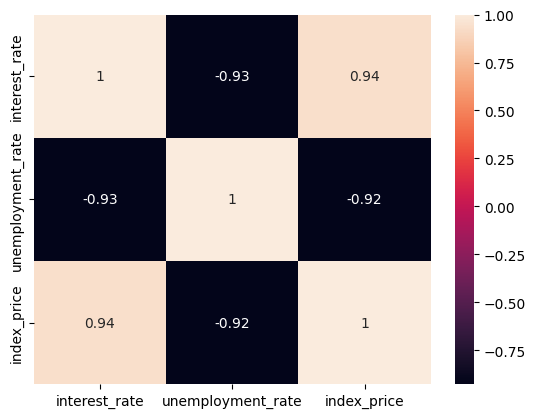

In [ ]:
sns.heatmap(df_index.corr(),annot=True)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

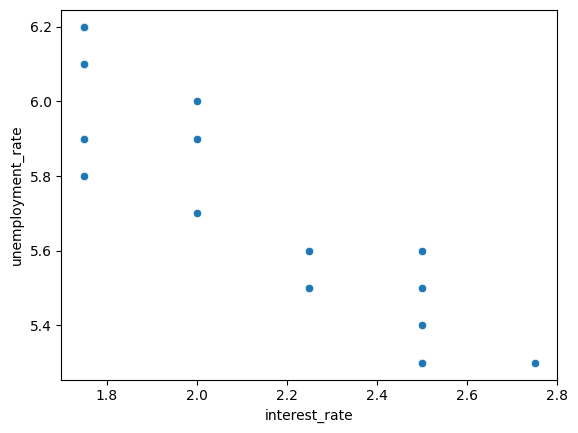

In [ ]:
sns.scatterplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

In [ ]:
# Get independent and dependent feature
X=df_index[['interest_rate','unemployment_rate']]
y=df_index['index_price']

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

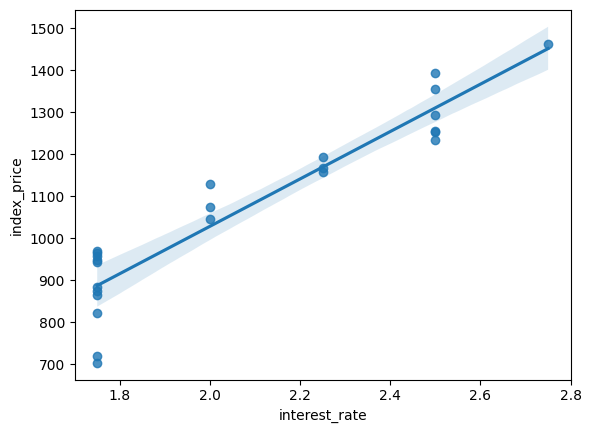

In [ ]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

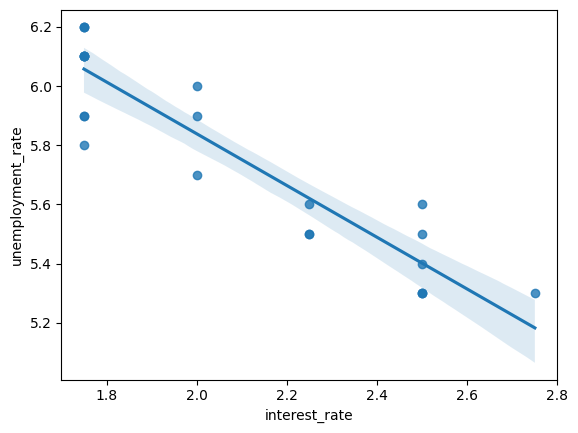

In [ ]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

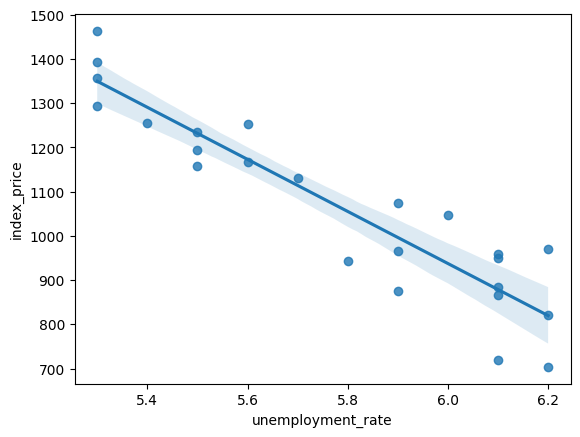

In [ ]:
sns.regplot(x='unemployment_rate', y='index_price', data=df_index)

In [ ]:
#Standardizaation
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
#Regression Model Training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(X_test)

In [ ]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [ ]:
y_test

,index_price
8,1159
16,971
0,1464
18,884
11,1075
9,1167


In [ ]:
# get coefficient and intercept
print("Slope of the best fit line:",lr.coef_)
print("Intercept of the best fit line:",lr.intercept_)

Slope of the best fit line: [  88.27275507 -116.25716066]
Intercept of the best fit line: 1053.4444444444443


In [ ]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [ ]:
model.predict(X_test)

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])

In [ ]:
print(model.summary()) # Comparing coefficent of both independent feature with the value we got from Linear Regression Model

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 12 Apr 2026   Prob (F-statistic):                       0.754
Time:                        10:32:10   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# Assumptions

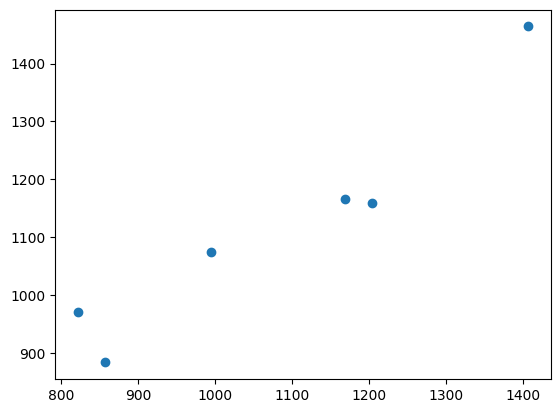

In [ ]:
#1: Linear Relationship between predicted and actual values

plt.scatter(y_pred,y_test)

In [ ]:
#2: Errors when plotted give normal distrbution or alike

residuals=y_test-y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


/tmp/ipykernel_3984/3762910054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='index_price', ylabel='Density'>

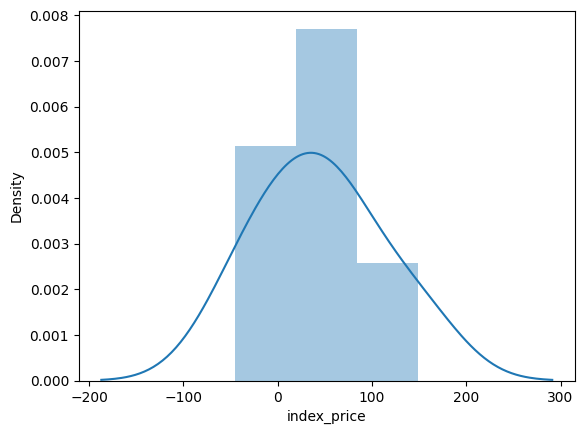

In [ ]:
sns.distplot(residuals,kde=True)

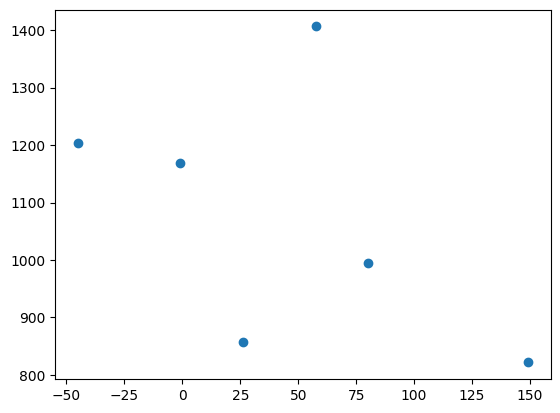

In [ ]:
# 3 Uniformly distrubted plot between predicted values and residuals
plt.scatter(residuals,y_pred)